 SCENARIO 1 – K-NEAREST NEIGHBORS (KNN)

 

Problem Statement

Predict whether a tumor is benign or malignant based on medical measurements.

 

Dataset (Kaggle – Public)

Breast Cancer Dataset
 

Target Variable: Diagnosis (Benign / Malignant)

Input Feature:

• Radius

• Texture

• Perimeter

• Area

• Smoothness

 

IN-LAB TASKS (KNN Classification)

1. Import required Python libraries.

2. Load the Breast Cancer dataset.

3. Perform data inspection & preprocessing.

4. Encode target labels.

5. Apply feature scaling (very important for KNN).

6. Split dataset into training and testing sets.

7. Train a KNN classifier.

8. Experiment with different values of K.

9. Predict diagnosis labels.

10. Evaluate performance using:

• Accuracy

• Precision / Recall / F1 Score

11. Identify misclassified cases.

12. Analyze model sensitivity to K.

 

Visualization

• Confusion Matrix

• Accuracy vs K Plot

• Decision Boundary (using two features) 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from matplotlib.colors import ListedColormap

Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_

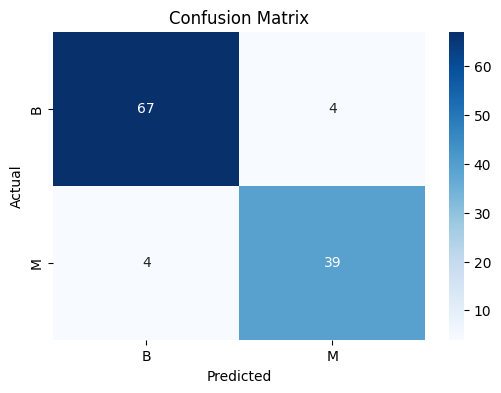

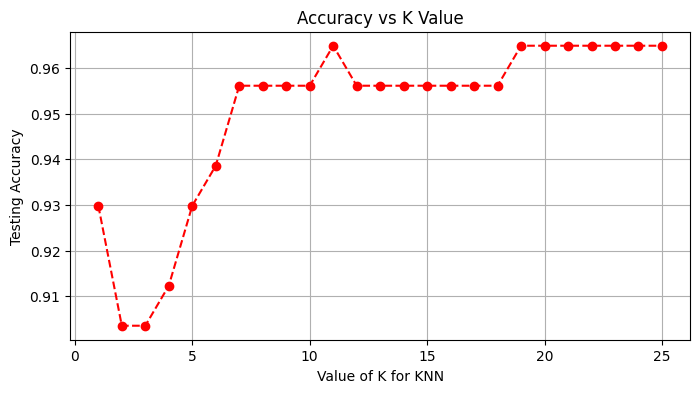

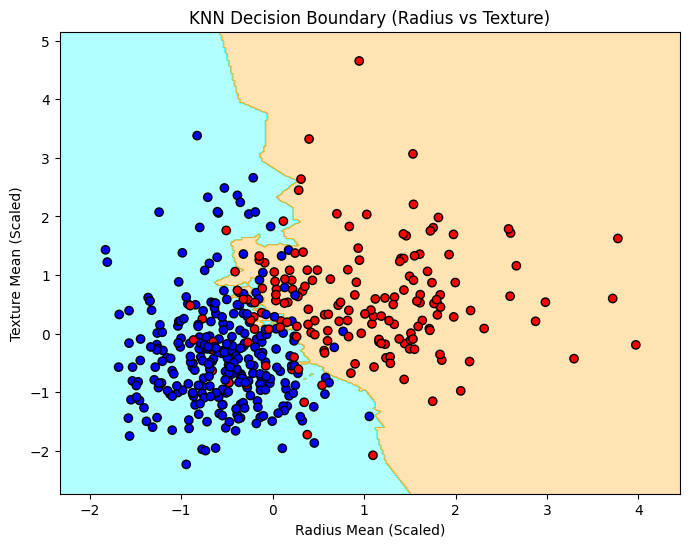

In [5]:
# 1 & 2. Load and Fix the dataset
df = pd.read_csv(r"C:\Users\Rithesh\Downloads\archive (1)\breast-cancer.csv")

# Convert numeric columns to float (they were strings after splitting)
numeric_cols = [col for col in df.columns if col not in ['id', 'diagnosis']]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# 3. Data inspection & preprocessing
print("Dataset Head:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())

# Define input features and target
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
X = df[features]
y = df['diagnosis']

# 4. Encode target labels (Malignant=M, Benign=B)
le = LabelEncoder()
y = le.fit_transform(y)
class_names = le.classes_

# 5. Apply feature scaling (Critical for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Split dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 7 & 8. Experiment with different values of K
k_range = range(1, 26)
scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

# 9 & 10. Predict and Evaluate performance for the best K (e.g., K=5)
best_k = 5
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred_final = knn_final.predict(X_test)

print(f"\nEvaluation for K={best_k}:")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final, target_names=class_names))

# 11. Identify misclassified cases
misclassified_indices = np.where(y_test != y_pred_final)[0]
print(f"\nNumber of misclassified cases: {len(misclassified_indices)}")

# --- VISUALIZATIONS ---

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')

# Accuracy vs K Plot
plt.figure(figsize=(8, 4))
plt.plot(k_range, scores, marker='o', linestyle='dashed', color='red')
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')
plt.title('Accuracy vs K Value')
plt.grid(True)
plt.savefig('accuracy_vs_k.png')

# Decision Boundary (using first two features: Radius vs Texture)
def plot_decision_boundaries(X, y, model, labels):
    X_reduced = X[:, :2] 
    model.fit(X_reduced, y)
    
    h = .02
    x_min, x_max = X_reduced[:, 0].min() - 0.5, X_reduced[:, 0].max() + 0.5
    y_min, y_max = X_reduced[:, 1].min() - 0.5, X_reduced[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('cyan', 'orange')))
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, edgecolors='k', cmap=ListedColormap(('blue', 'red')))
    plt.xlabel('Radius Mean (Scaled)')
    plt.ylabel('Texture Mean (Scaled)')
    plt.title('KNN Decision Boundary (Radius vs Texture)')
    plt.savefig('decision_boundary.png')

plot_decision_boundaries(X_train, y_train, KNeighborsClassifier(n_neighbors=best_k), class_names)

SCENARIO 2 – DECISION TREE CLASSIFIER

 

Problem Statement

Predict whether a loan application should be approved or rejected.

 

Dataset (Public / Standard Dataset)

Loan Prediction Dataset

Dataset Link: https://www.kaggle.com/datasets/ninzaami/loan-predication

 

Target Variable: Loan Status (Approved / Rejected)

Input Features

• Applicant Income

• Loan Amount

• Credit History

• Education

• Property Area

 

IN-LAB TASKS (Decision Tree Classification)

1. Import required Python libraries.

2. Load the Loan Prediction dataset.

3. Perform preprocessing:

• Handle missing values

• Encode categorical variables

4. Split dataset into training and testing sets.

5. Train a Decision Tree classifier.

6. Experiment with tree depth / pruning.

7. Predict loan status.

8. Evaluate performance using:

• Accuracy

• Precision / Recall / F1 Score

9. Analyze feature importance.

10. Detect overfitting behavior.

11. Compare shallow vs deep trees.

 visualization

• Confusion Matrix

• Tree Structure Plot

• Feature Importance Plot 

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2     

C:\Users\Rithesh\AppData\Local\Temp\ipykernel_27476\231112677.py:29: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Rithesh\AppData\Local\Temp\ipykernel_27476\231112677.py:29: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignme

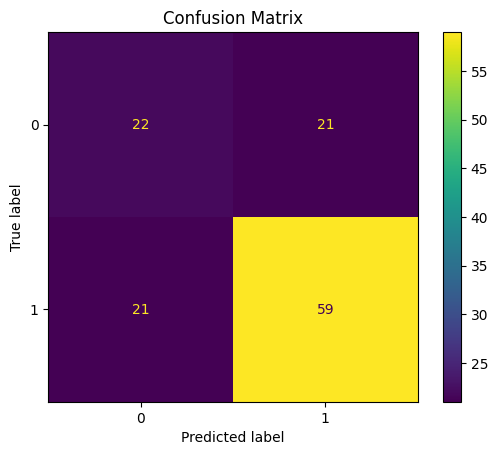

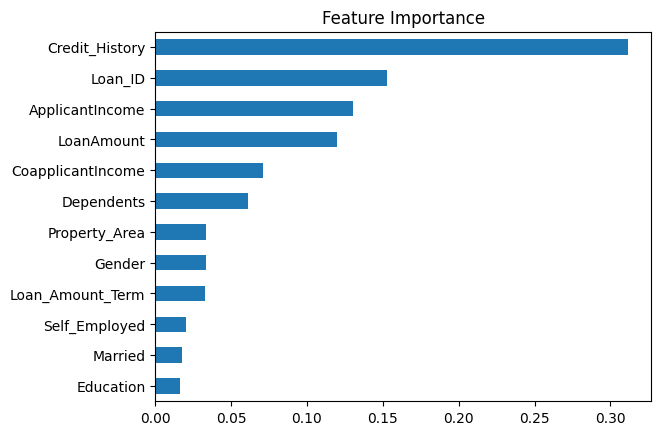

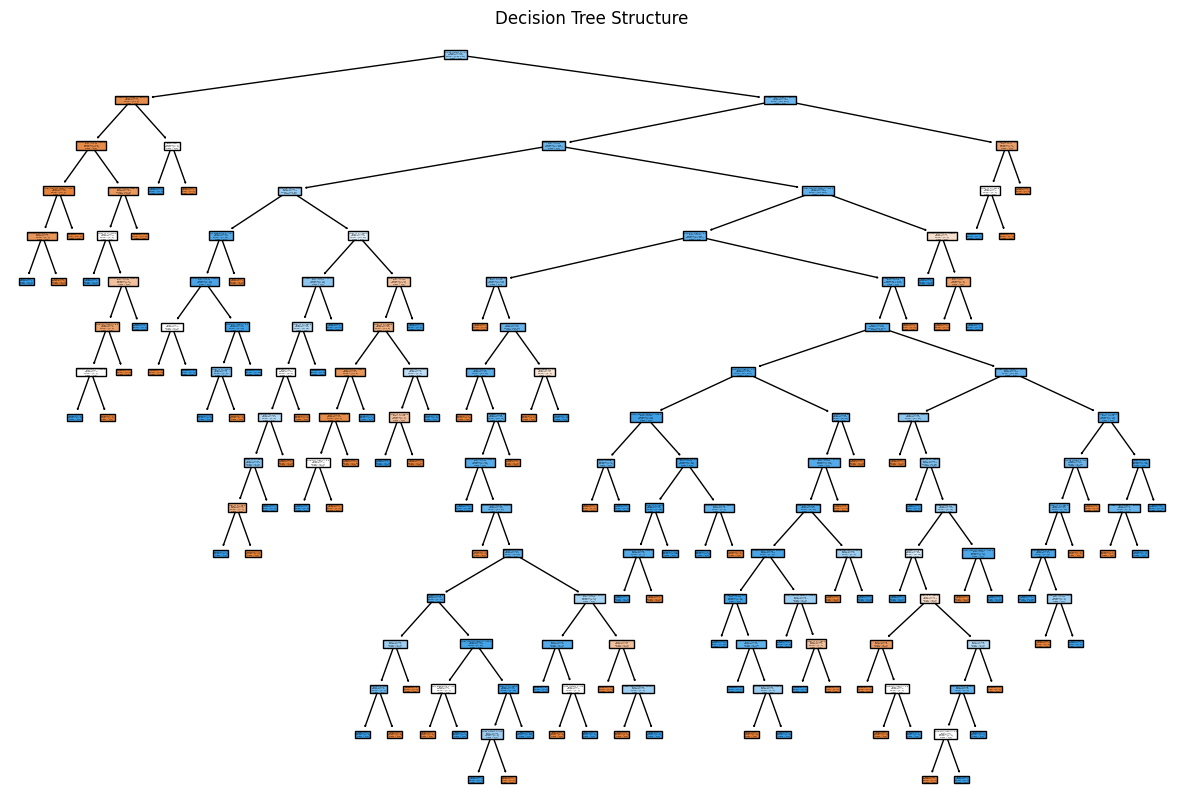


Shallow Tree Accuracy (Train): 0.8228105906313645
Shallow Tree Accuracy (Test): 0.7886178861788617

Deep Tree Accuracy (Train): 1.0
Deep Tree Accuracy (Test): 0.6585365853658537


In [ ]:
# RITHESH P _ 24BAD098

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Load Dataset

df = pd.read_csv(r"C:\Users\Rithesh\Downloads\archive (2)\train_u6lujuX_CVtuZ9i (1).csv")   # change filename if needed

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)


print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True)
plt.title("Decision Tree Structure")
plt.show()


# Shallow Tree
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

train_acc_shallow = dt_shallow.score(X_train, y_train)
test_acc_shallow = dt_shallow.score(X_test, y_test)

# Deep Tree
dt_deep = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_deep.fit(X_train, y_train)

train_acc_deep = dt_deep.score(X_train, y_train)
test_acc_deep = dt_deep.score(X_test, y_test)

print("\nShallow Tree Accuracy (Train):", train_acc_shallow)
print("Shallow Tree Accuracy (Test):", test_acc_shallow)

print("\nDeep Tree Accuracy (Train):", train_acc_deep)
print("Deep Tree Accuracy (Test):", test_acc_deep)
